In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
df = pd.read_csv("/content/car data.csv")

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [17]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [18]:
df.columns = df.columns.str.strip()

In [19]:
df = df.select_dtypes(exclude=['object'])

In [20]:
target = None

for col in df.columns:
    if col.lower() in ['price', 'selling_price']:
        target = col
        break

if target is None:
    raise Exception("Price column not found")

In [21]:
X = df.drop(target, axis=1)
y = df[target]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Done")

Model Training Done


In [28]:
y_pred = model.predict(X_test)

In [29]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result)

    Actual Price  Predicted Price
0           0.35         2.109163
1          10.11         8.845231
2           4.95         4.950550
3           0.15        -1.147597
4           6.95        10.142302
..           ...              ...
56          5.50         4.352918
57          9.50         7.792763
58          2.10         1.504200
59          7.40         6.209602
60          0.30         0.846122

[61 rows x 2 columns]


In [25]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 4.125555394836821
R2 Score: 0.8209051135124033


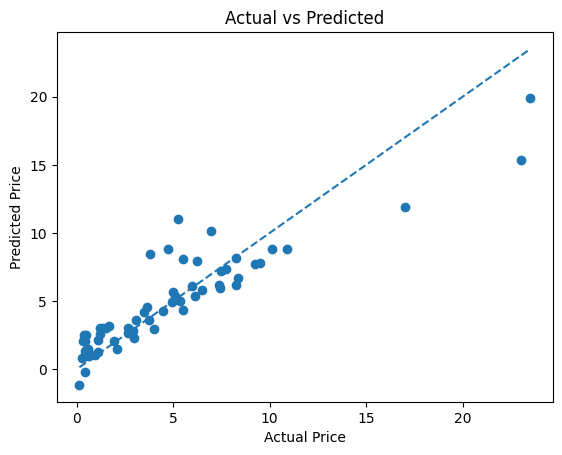

In [26]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')   # reference line

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()